✅ Données chargées et nettoyées.
✅ Traduction (Encoding) terminée.
⏳ Calcul de l'Information Mutuelle en cours...
✅ Calcul terminé !

🏆 TOP 10 des Features les plus importantes :
OverallQual     0.581262
Neighborhood    0.569813
GrLivArea       0.496909
YearBuilt       0.437939
GarageArea      0.415014
TotalBsmtSF     0.390280
GarageCars      0.381467
FirstFlrSF      0.368825
BsmtQual        0.364779
KitchenQual     0.326194
Name: MI Scores, dtype: float64


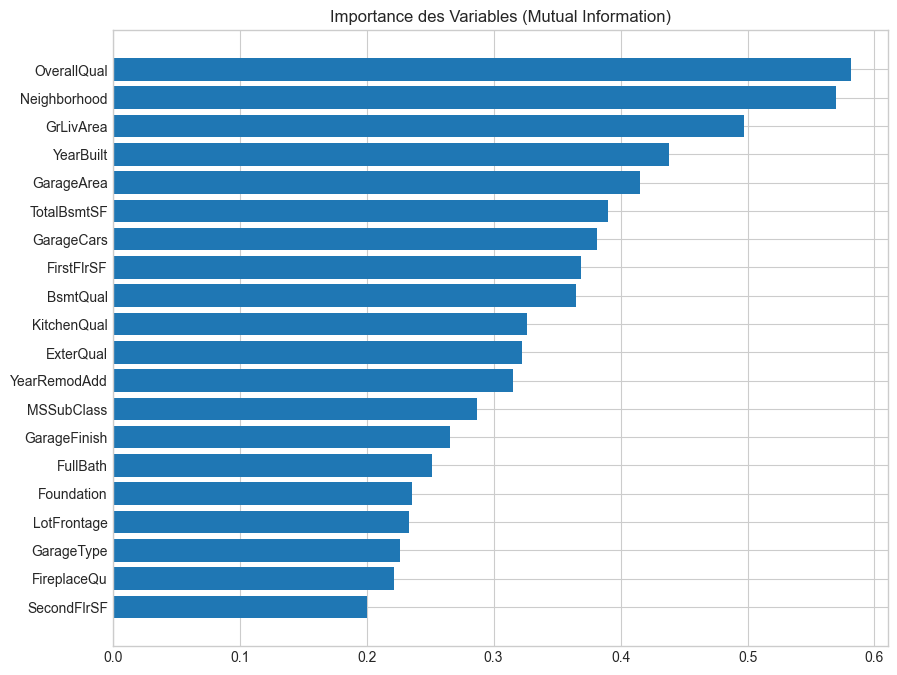

In [1]:
# --- BLOC 1 : IMPORTATIONS ---
# On appelle nos outils.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Configuration pour que les graphiques soient jolis
plt.style.use("seaborn-v0_8-whitegrid")

# --- BLOC 2 : CHARGEMENT ET NETTOYAGE ---
# On charge ton fichier CSV
df = pd.read_csv("ames.csv")

# Séparation des Features (X) et de la Target (y)
# On veut prédire le "SalePrice"
X = df.copy()
y = X.pop("SalePrice")

# ⚠️ NETTOYAGE D'URGENCE ⚠️
# L'algorithme MI déteste les cases vides (NaN).
# Pour les colonnes TEXTE (Object), on remplit les vides par "Unknown"
for col in X.select_dtypes("object"):
    X[col] = X[col].fillna("Unknown")

# Pour les colonnes CHIFFRES (Number), on remplit les vides par la moyenne
for col in X.select_dtypes("number"):
    X[col] = X[col].fillna(X[col].mean())

print("✅ Données chargées et nettoyées.")

# --- BLOC 3 : L'ENCODAGE (LA MAGIE) ---
# C'est ici qu'on traduit le TEXTE en CHIFFRES pour l'algo.
# On garde en mémoire quelles colonnes étaient du texte pour les traiter comme "discrètes"
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# Maintenant, tout ton tableau X ne contient que des chiffres.
print("✅ Traduction (Encoding) terminée.")

# --- BLOC 4 : FONCTION DE CALCUL MI ---
# On prépare le masque pour dire à l'algo : "Ces colonnes sont des catégories (discrètes)"
discrete_features = X.dtypes == int

def make_mi_scores(X, y, discrete_features):
    # C'est la ligne qui fait tout le calcul mathématique
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    
    # Mise en forme du résultat
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

print("⏳ Calcul de l'Information Mutuelle en cours...")
mi_scores = make_mi_scores(X, y, discrete_features)
print("✅ Calcul terminé !")

# --- BLOC 5 : AFFICHAGE DES RÉSULTATS ---
print("\n🏆 TOP 10 des Features les plus importantes :")
print(mi_scores.head(10))

# --- BLOC 6 : VISUALISATION ---
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Importance des Variables (Mutual Information)")

plt.figure(dpi=100, figsize=(10, 8))
# On affiche les 20 meilleures
plot_mi_scores(mi_scores.head(20))
plt.show()